# Problem 3 — Event Impact Optimization (End-to-End Notebook)

This notebook implements the **full system** required for **Problem 3**:

1. **Baseline (counterfactual) demand forecast** (no promotions)
2. **Causal-ish promotion effect model** (lift + cannibalization + margin impact)
3. **Capacity-aware simulator**
4. **Constrained optimizer** (≤ 3 promos, no Q1 promos, capacity respected, volatility constrained)
5. **Uncertainty simulation** (Monte Carlo)

It is designed to run directly on the dataset in `HVAC Challenge AI-ML Track/data/`.

---

## Expected folder layout

Either:
- Place the extracted zip folder next to this notebook, so you have:
```
./HVAC Challenge AI-ML Track/
    data/
    notebooks/
    ...
```

Or set `DATA_ROOT` below to wherever the extracted folder lives.


In [1]:
# =========================
# 0) Imports & configuration
# =========================
import os
import json
import math
import itertools
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import HistGradientBoostingRegressor

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---- Core knobs ----
TARGET_YEAR = 2025          # optimize promo plan for this year
TOP_K = 10                  # candidates retained before combo search
MAX_CANDIDATES = 200        # cap candidate count for speed

MAX_PROMOS = 3              # constraint: max promos per year
NO_PROMO_MONTHS = {1,2,3}   # constraint: no Q1 promos
VAR_LIMIT_RATIO = 1.00      # variance must be <= baseline_variance * ratio (point-estimate baseline variance)

# ---- Robust / expected-quality knobs ----
# Optimization uses a smaller MC bank; final reporting uses larger MC bank.
N_SCENARIOS_OPT = 5
N_SCENARIOS_REPORT = 20

# Chance constraint: require P(variance <= limit) >= CHANCE_LEVEL
CHANCE_LEVEL = 0.90

# Optional "growth target" constraint (set to 0.0 to disable)
MIN_MEAN_UPLIFT_PCT = 0.0

# Pick final schedule by:
#   - maximize mean_profit (under scenarios), tie-break by CVaR
RISK_ALPHA_CVAR = 0.10

# Candidate combos to MC-evaluate after deterministic screening
COMBO_MC_TOP = 5

# Cannibalization distribution weights
# prebuy: (m-1, m-2), postbuy: (m+1, m+2)
PREBUY_WEIGHTS = (0.6, 0.4)
POSTBUY_WEIGHTS = (0.6, 0.4)

# ---- OOD guardrails ----
# Recommended: restrict candidate (promo_type, discount, duration) to observed history
FILTER_TO_OBSERVED_PROMOS = True
# If you must allow unobserved values, apply an extrapolation penalty (set to 0.0 to disable)
OOD_PENALTY_ALPHA = 0.0

# ---- Uncertainty calibration ----
# Baseline: sample residual vectors from historical years to preserve realistic seasonality + cross-product correlation
BASELINE_RESIDUAL_SAMPLING = "year"  # "year" or "month"
BASELINE_NOISE_SCALE = 1.0

# Promo effects: bootstrap residuals from year-based CV rather than i.i.d. Gaussian
EFFECT_NOISE_SCALE = 1.0

# Candidate grid:
# If left as None, we auto-derive grids from promotion_history (recommended).
DISCOUNT_GRID = None
DURATION_GRID = None

# Output folder
RESULTS_DIR = Path('results_problem3')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('Configured TARGET_YEAR =', TARGET_YEAR)


Configured TARGET_YEAR = 2025


## 1) Locate data and load CSVs


In [2]:

# =========================
# 1) Load data
# =========================
DATA_DIR = 'data'

demand_history = pd.read_csv(DATA_DIR + '/demand_history.csv')
promotion_history = pd.read_csv(DATA_DIR + '/promotion_history.csv')
capacity_constraints = pd.read_csv(DATA_DIR + '/capacity_constraints.csv')
external_signals = pd.read_csv(DATA_DIR + '/external_signals.csv')
unit_economics = pd.read_csv(DATA_DIR + '/unit_economics.csv')

print('Loaded:')
print(' demand_history:', demand_history.shape)
print(' promotion_history:', promotion_history.shape)
print(' capacity_constraints:', capacity_constraints.shape)
print(' external_signals:', external_signals.shape)
print(' unit_economics:', unit_economics.shape)

demand_history.head()


Loaded:
 demand_history: (92, 15)
 promotion_history: (80, 13)
 capacity_constraints: (240, 4)
 external_signals: (48, 11)
 unit_economics: (5, 4)


,product,aps,year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,AH,ACNF,2022,10733,10328,11188,13739,14420,14603,16511,14448,15313,14503,11708,8903
1,AH,ACNF,2023,10986,10045,12266,14883,15757,16825,18040,15043,15044,13479,13493,10554
2,AH,ACNF,2024,11780,11171,12055,15155,16929,17593,19231,17170,16159,13870,11529,12644
3,AH,ACNF,2025,12858,10793,13054,16149,18015,17905,19817,17575,17790,15962,13540,11776
4,AH,AH_FIT,2022,7499,6928,7445,8990,9704,10243,11236,9334,10446,9331,7715,6057


## 2) Prepare demand time-series (monthly, product totals)

We optimize at **product total** level using `aps == "ALL"` so it aligns with capacity and unit economics.


In [3]:

# =========================
# 2) Prepare demand (long format)
# =========================
MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
MONTH_TO_NUM = {m:i+1 for i,m in enumerate(MONTHS)}
NUM_TO_MONTH = {i+1:m for i,m in enumerate(MONTHS)}

demand_all = demand_history[demand_history['aps'].astype(str).str.upper() == 'ALL'].copy()
assert len(demand_all) > 0, "No APS=='ALL' rows found in demand_history.csv"

demand_long = demand_all.melt(
    id_vars=['product','aps','year'],
    value_vars=MONTHS,
    var_name='month_name',
    value_name='demand_units'
)
demand_long['month'] = demand_long['month_name'].map(MONTH_TO_NUM).astype(int)

# Merge external signals
demand_long = demand_long.merge(external_signals, on=['year','month'], how='left')

# Cyclical month encoding
demand_long['month_sin'] = np.sin(2*np.pi*demand_long['month']/12.0)
demand_long['month_cos'] = np.cos(2*np.pi*demand_long['month']/12.0)

demand_long = demand_long.sort_values(['product','year','month']).reset_index(drop=True)
demand_long.head()


,product,aps,year,month_name,demand_units,month,avg_temp_f,heating_degree_days,cooling_degree_days,housing_starts_k,building_permits_k,gdp_growth_pct,consumer_confidence,energy_price_idx,interest_rate_pct,month_sin,month_cos
0,AH,ALL,2022,Jan,50659,1,29.3,1072.0,0.0,1299.0,1422.0,0.82,103.3,109.4,3.78,0.500000,8.660254e-01
1,AH,ALL,2022,Feb,48423,2,29.5,1066.0,0.0,1315.0,1394.0,0.44,102.9,114.9,3.75,0.866025,5.000000e-01
2,AH,ALL,2022,Mar,52718,3,43.4,647.0,0.0,1485.0,1614.0,1.38,102.8,94.6,3.86,1.000000,6.123234e-17
3,AH,ALL,2022,Apr,66264,4,56.1,266.0,0.0,1569.0,1722.0,0.56,93.9,108.3,3.62,0.866025,-5.000000e-01
4,AH,ALL,2022,May,68517,5,65.8,0.0,23.0,1611.0,1807.0,0.72,94.0,112.2,3.93,0.500000,-8.660254e-01


## 3) Baseline demand model (counterfactual “no promo” forecast)

We train models using **years < TARGET_YEAR** and forecast baseline demand for `TARGET_YEAR`.
This becomes the “no-promo” reference that the simulator compares against.


In [4]:

# =========================
# 3) Baseline forecast model
# =========================
signal_cols = [
    'avg_temp_f','heating_degree_days','cooling_degree_days',
    'housing_starts_k','building_permits_k','gdp_growth_pct',
    'consumer_confidence','energy_price_idx','interest_rate_pct'
]

baseline_feature_cols = ['year','month_sin','month_cos'] + signal_cols

def make_regressor():
    # Strong tabular baseline for hackathon setting
    return HistGradientBoostingRegressor(
        random_state=RANDOM_SEED,
        max_depth=6,
        learning_rate=0.06,
        max_iter=500,
        l2_regularization=0.1
    )

baseline_models = {}
baseline_resid_std = {}
baseline_residual_records = []

train_mask = demand_long['year'] < TARGET_YEAR
test_mask  = demand_long['year'] == TARGET_YEAR

baseline_forecasts = []

for product, df_p in demand_long.groupby('product'):
    df_train = df_p[train_mask].copy()
    df_test  = df_p[test_mask].copy()
    if len(df_test) != 12:
        print(f'Warning: {product} has {len(df_test)} rows in TARGET_YEAR')

    X_train = df_train[baseline_feature_cols]
    y_train = df_train['demand_units'].astype(float)

    model = make_regressor()
    model.fit(X_train, y_train)
    baseline_models[product] = model

    # Residuals on training data (used for calibrated, correlated uncertainty)
    yhat_train = model.predict(X_train)
    resid = (y_train - yhat_train).astype(float)
    baseline_resid_std[product] = float(np.std(resid))

    r = df_train[['year','month']].copy()
    r['product'] = product
    r['resid'] = resid.values
    baseline_residual_records.append(r)

    # Forecast baseline for target year
    X_test = df_test[baseline_feature_cols]
    yhat = model.predict(X_test)

    out = df_test[['product','year','month']].copy()
    out['baseline_mean'] = np.maximum(yhat, 0.0)
    # keep std for diagnostics; simulator uses residual bootstrap by default
    out['baseline_std'] = baseline_resid_std[product]
    baseline_forecasts.append(out)

baseline_forecast_df = pd.concat(baseline_forecasts, ignore_index=True)

# ---- Build residual "library" for realistic scenario simulation ----
baseline_residuals_df = pd.concat(baseline_residual_records, ignore_index=True)

# Pivot residuals into (year, month) x product matrix
resid_pivot = baseline_residuals_df.pivot_table(
    index=['year','month'], columns='product', values='resid', aggfunc='mean'
).sort_index()

prod_order = sorted(resid_pivot.columns.tolist())
prod_to_j = {p:j for j,p in enumerate(prod_order)}

# Identify complete years (all 12 months and all products present, no NaN)
complete_years = []
for y in sorted(baseline_residuals_df['year'].dropna().unique()):
    y = int(y)
    try:
        sub = resid_pivot.xs(y, level='year')
    except KeyError:
        continue
    if set(sub.index.tolist()) == set(range(1,13)) and sub.reindex(range(1,13)).notna().all().all():
        complete_years.append(y)

print('Residual bootstrap: complete_years =', complete_years)

def sample_baseline_resid_mat(rng, mode=BASELINE_RESIDUAL_SAMPLING):
    """Return residual matrix shape (12, n_products) aligned to prod_order."""
    if (mode == "year") and (len(complete_years) > 0):
        y = int(rng.choice(complete_years))
        mat = resid_pivot.xs(y, level='year').reindex(range(1,13))[prod_order].values
        return mat

    # Fallback: month-wise sampling (preserves seasonality, but less autocorrelation)
    mats = []
    for m in range(1,13):
        pool = resid_pivot.xs(m, level='month', drop_level=False)
        ridx = int(rng.integers(0, len(pool)))
        mats.append(pool.iloc[ridx][prod_order].values)
    return np.vstack(mats)

baseline_forecast_df.head(12)


C:\Users\rupes\AppData\Local\Temp\ipykernel_15692\162772908.py:32: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_train = df_p[train_mask].copy()
C:\Users\rupes\AppData\Local\Temp\ipykernel_15692\162772908.py:33: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_test  = df_p[test_mask].copy()
C:\Users\rupes\AppData\Local\Temp\ipykernel_15692\162772908.py:32: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_train = df_p[train_mask].copy()
C:\Users\rupes\AppData\Local\Temp\ipykernel_15692\162772908.py:33: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_test  = df_p[test_mask].copy()
C:\Users\rupes\AppData\Local\Temp\ipykernel_15692\162772908.py:32: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_train = df_p[train_mask].copy()
C:\Users\rupes\AppData\Local\Temp\ipykernel_15692\162772908.py:33: UserWarning: Boolean Series key wil

Residual bootstrap: complete_years = [2022, 2023, 2024]


,product,year,month,baseline_mean,baseline_std
0,AH,2025,1,65514.583333,11599.576104
1,AH,2025,2,65514.583333,11599.576104
2,AH,2025,3,65514.583333,11599.576104
3,AH,2025,4,65514.583333,11599.576104
4,AH,2025,5,65514.583333,11599.576104
5,AH,2025,6,65514.583333,11599.576104
6,AH,2025,7,65514.583333,11599.576104
7,AH,2025,8,65514.583333,11599.576104
8,AH,2025,9,65514.583333,11599.576104
9,AH,2025,10,65514.583333,11599.576104


AH: MAE=12,340  RMSE=14,975
CL: MAE=7,469  RMSE=8,260
CN: MAE=9,042  RMSE=10,463
FN: MAE=9,537  RMSE=11,109
HP: MAE=14,528  RMSE=16,696


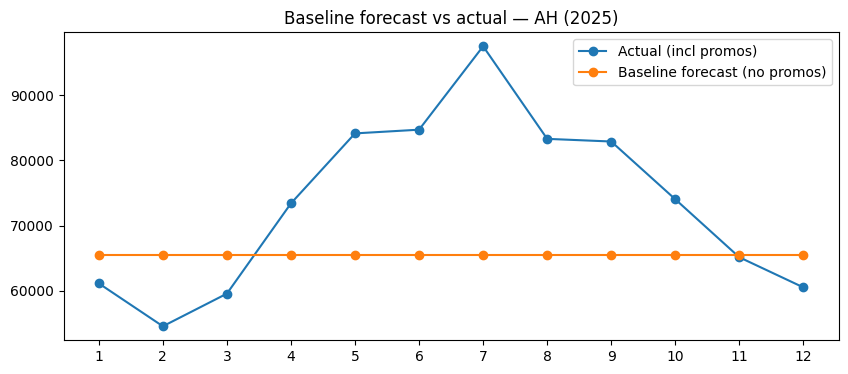

In [5]:

# Quick sanity check: baseline vs actual for TARGET_YEAR (note: actual includes real-world promo effects)
tmp = demand_long[demand_long['year']==TARGET_YEAR][['product','year','month','demand_units']].merge(
    baseline_forecast_df, on=['product','year','month'], how='left'
)

for product in sorted(tmp['product'].unique()):
    d = tmp[tmp['product']==product].sort_values('month')
    mae = mean_absolute_error(d['demand_units'], d['baseline_mean'])
    rmse = mean_squared_error(d['demand_units'], d['baseline_mean']) ** 0.5
    print(f'{product}: MAE={mae:,.0f}  RMSE={rmse:,.0f}')

# Plot one product example
p0 = sorted(tmp['product'].unique())[0]
d0 = tmp[tmp['product']==p0].sort_values('month')
plt.figure(figsize=(10,4))
plt.plot(d0['month'], d0['demand_units'], marker='o', label='Actual (incl promos)')
plt.plot(d0['month'], d0['baseline_mean'], marker='o', label='Baseline forecast (no promos)')
plt.xticks(range(1,13))
plt.title(f'Baseline forecast vs actual — {p0} ({TARGET_YEAR})')
plt.legend()
plt.show()


## 4) Promotion effect models (lift, prebuy, postbuy, margin impact)

We train “contextual uplift” models on `promotion_history.csv` using **years < TARGET_YEAR**.
These predict promo effects from:
- product, promo_type
- discount_pct, duration_days
- month + external signals


In [6]:

# =========================
# 4) Promo effect models
# =========================
# Map promo month (string like 'Jun') to month number
promotion_history = promotion_history.copy()
promotion_history['month_num'] = promotion_history['month'].map(MONTH_TO_NUM).astype(int)

# Join external signals
promo = promotion_history.merge(
    external_signals,
    left_on=['year','month_num'],
    right_on=['year','month'],
    how='left',
    suffixes=('','_sig')
)

# Feature set
promo_feature_cols = ['product','promo_type','discount_pct','duration_days','month_num'] + signal_cols
target_cols = ['lift_pct','prebuy_pct','postbuy_pct','margin_impact_pct']

# Train on years < TARGET_YEAR
promo_train = promo[promo['year'] < TARGET_YEAR].copy()

categorical = ['product','promo_type']
numeric = [c for c in promo_feature_cols if c not in categorical]

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]), numeric)
    ],
    remainder='drop'
)

def make_effect_pipeline():
    return Pipeline(steps=[
        ('prep', preprocess),
        ('model', HistGradientBoostingRegressor(
            random_state=RANDOM_SEED,
            max_depth=5,
            learning_rate=0.06,
            max_iter=400,
            l2_regularization=0.1
        ))
    ])

# ---- Year-based CV to estimate residual distributions (for calibrated noise) ----
years_cv = sorted(promo_train['year'].dropna().unique().astype(int).tolist())
effect_residuals = {t: [] for t in target_cols}
effect_rmse = {}

for tgt in target_cols:
    # Collect out-of-year predictions for residuals
    y_true_all = []
    y_pred_all = []
    for y in years_cv:
        tr = promo_train[promo_train['year'] != y]
        va = promo_train[promo_train['year'] == y]
        if len(va) == 0 or len(tr) == 0:
            continue
        Xtr = tr[promo_feature_cols].copy()
        ytr = tr[tgt].astype(float)
        Xva = va[promo_feature_cols].copy()
        yva = va[tgt].astype(float)

        m = make_effect_pipeline()
        m.fit(Xtr, ytr)
        yhat = m.predict(Xva)

        y_true_all.append(yva.values)
        y_pred_all.append(yhat)
        effect_residuals[tgt].append((yva.values - yhat))

    if len(y_true_all) == 0:
        # Fallback: in-sample residuals (should not happen unless tiny data)
        Xall = promo_train[promo_feature_cols].copy()
        yall = promo_train[tgt].astype(float)
        m = make_effect_pipeline()
        m.fit(Xall, yall)
        yhat = m.predict(Xall)
        resid = (yall.values - yhat)
        effect_residuals[tgt] = resid
        effect_rmse[tgt] = float(np.sqrt(np.mean(resid**2)))
    else:
        yt = np.concatenate(y_true_all)
        yp = np.concatenate(y_pred_all)
        resid = np.concatenate(effect_residuals[tgt])
        effect_residuals[tgt] = resid
        effect_rmse[tgt] = float(np.sqrt(np.mean((yt-yp)**2)))

# Train final models on all promo_train
effect_models = {}
Xtr_full = promo_train[promo_feature_cols].copy()
for tgt in target_cols:
    ytr_full = promo_train[tgt].astype(float)
    m = make_effect_pipeline()
    m.fit(Xtr_full, ytr_full)
    effect_models[tgt] = m

print('Effect CV RMSE:', effect_rmse)
for k,v in effect_residuals.items():
    print(k, 'residuals:', len(v))

# Auto-derive candidate grids from observed history (recommended)
if DISCOUNT_GRID is None:
    DISCOUNT_GRID = sorted(promo_train['discount_pct'].dropna().unique().astype(float).tolist())
if DURATION_GRID is None:
    DURATION_GRID = sorted(promo_train['duration_days'].dropna().unique().astype(int).tolist())

print('DISCOUNT_GRID:', DISCOUNT_GRID)
print('DURATION_GRID:', DURATION_GRID)


Effect CV RMSE: {'lift_pct': 5.913935976101803, 'prebuy_pct': 1.5034266824554932, 'postbuy_pct': 2.337383432842268, 'margin_impact_pct': 1.553774296541431}
lift_pct residuals: 60
prebuy_pct residuals: 60
postbuy_pct residuals: 60
margin_impact_pct residuals: 60
DISCOUNT_GRID: [0.0, 3.0, 3.4, 3.6, 4.0, 4.3, 4.6, 4.7, 5.8, 6.0, 6.2, 6.3, 6.4, 6.6, 7.4, 7.5, 7.6, 7.7, 7.8, 8.0, 8.2, 8.4, 8.6, 8.9, 9.5, 9.8, 10.0, 10.4, 11.3, 11.4, 12.3, 12.4, 13.1, 14.3, 14.4, 14.6]
DURATION_GRID: [14, 21, 30]


## 5) Simulator (capacity-aware + cannibalization)

Given a **promo schedule** (up to 3 promos), simulate month-by-month:
- promo-month lift
- prebuy/postbuy cannibalization spillover
- capacity clipping
- profit using unit economics + predicted margin impact

Outputs:
- final demand per product-month
- lost sales
- total profit
- total-demand variance (volatility)


In [7]:

# =========================
# 5) Simulator
# =========================
# Capacity for TARGET_YEAR
cap_y = capacity_constraints[capacity_constraints['year']==TARGET_YEAR].copy()
cap_y = cap_y.rename(columns={'capacity_units':'capacity'})
cap_y = cap_y[['product','month','capacity']]

# Unit economics
ue = unit_economics.set_index('product').copy()
ue['gross_profit_per_unit'] = ue['avg_selling_price'] - ue['unit_cost']

# Baseline demand table for TARGET_YEAR
base_y = baseline_forecast_df.copy()
base_y = base_y[base_y['year']==TARGET_YEAR][['product','month','baseline_mean','baseline_std']]
base_y = base_y.merge(cap_y, on=['product','month'], how='left')

# External signals for TARGET_YEAR (for effect predictions)
sig_y = external_signals[external_signals['year']==TARGET_YEAR].copy()

promo_types = sorted(promotion_history['promo_type'].unique())

def predict_effects(product, month_num, promo_type, discount_pct, duration_days):
    row = {
        'product': product,
        'promo_type': promo_type,
        'discount_pct': float(discount_pct),
        'duration_days': int(duration_days),
        'month_num': int(month_num)
    }
    sig = sig_y[sig_y['month']==month_num].iloc[0].to_dict()
    for c in signal_cols:
        row[c] = sig.get(c, np.nan)

    X = pd.DataFrame([row], columns=promo_feature_cols)
    preds = {t: float(effect_models[t].predict(X)[0]) for t in target_cols}

    # Guardrails: keep in sensible bounds
    preds['lift_pct'] = float(np.clip(preds['lift_pct'], -10, 60))
    preds['prebuy_pct'] = float(np.clip(preds['prebuy_pct'], 0, 30))
    preds['postbuy_pct'] = float(np.clip(preds['postbuy_pct'], 0, 30))
    preds['margin_impact_pct'] = float(np.clip(preds['margin_impact_pct'], -30, 10))
    return preds

def sample_effect_resid(tgt, rng):
    arr = np.asarray(effect_residuals[tgt], dtype=float)
    if arr.size == 0:
        return 0.0
    return float(arr[int(rng.integers(0, arr.size))])

def simulate_schedule(schedule_df, add_noise=False, rng=None,
                      baseline_resid_mat=None,
                      baseline_noise_scale=BASELINE_NOISE_SCALE,
                      effect_noise_scale=EFFECT_NOISE_SCALE):
    """
    schedule_df columns:
      product, month, promo_type, discount_pct, duration_days

    Noise model (expected-quality):
      - Baseline demand uncertainty uses residual bootstrap (year or month sampling) to preserve realistic structures.
      - Promo effect uncertainty bootstraps CV residuals rather than i.i.d. Gaussian.
    """
    if rng is None:
        rng = np.random.default_rng(RANDOM_SEED)

    # Build working demand frame
    sim = base_y.copy()
    sim['demand_raw'] = sim['baseline_mean'].astype(float)

    # Apply baseline uncertainty if requested
    if add_noise:
        if baseline_resid_mat is None:
            baseline_resid_mat = sample_baseline_resid_mat(rng)
        # baseline_resid_mat: (12, n_products) aligned to prod_order
        for p in sim['product'].unique():
            j = prod_to_j.get(p, None)
            if j is None:
                continue
            for m in range(1,13):
                idx = (sim['product']==p) & (sim['month']==m)
                v = float(sim.loc[idx, 'demand_raw'].iloc[0])
                v = v + float(baseline_resid_mat[m-1, j]) * float(baseline_noise_scale)
                sim.loc[idx, 'demand_raw'] = max(v, 0.0)

    # Track which months are promo months by product (for profit calc)
    sim['is_promo_month'] = False
    sim['promo_margin_impact_pct'] = 0.0  # only meaningful for promo months

    effects_list = []
    for _, ev in schedule_df.iterrows():
        p = ev['product']
        m0 = int(ev['month'])
        e = predict_effects(p, m0, ev['promo_type'], ev['discount_pct'], ev['duration_days'])

        # Add effect uncertainty if requested (bootstrap residuals from year-CV)
        if add_noise:
            e['lift_pct'] += sample_effect_resid('lift_pct', rng) * float(effect_noise_scale)
            e['prebuy_pct'] += sample_effect_resid('prebuy_pct', rng) * float(effect_noise_scale)
            e['postbuy_pct'] += sample_effect_resid('postbuy_pct', rng) * float(effect_noise_scale)
            e['margin_impact_pct'] += sample_effect_resid('margin_impact_pct', rng) * float(effect_noise_scale)

            e['lift_pct'] = float(np.clip(e['lift_pct'], -10, 60))
            e['prebuy_pct'] = float(np.clip(e['prebuy_pct'], 0, 30))
            e['postbuy_pct'] = float(np.clip(e['postbuy_pct'], 0, 30))
            e['margin_impact_pct'] = float(np.clip(e['margin_impact_pct'], -30, 10))

        # Promo month lift
        idx0 = (sim['product']==p) & (sim['month']==m0)
        base0 = float(sim.loc[idx0, 'demand_raw'].iloc[0])
        sim.loc[idx0, 'demand_raw'] = base0 * (1.0 + e['lift_pct']/100.0)
        sim.loc[idx0, 'is_promo_month'] = True
        sim.loc[idx0, 'promo_margin_impact_pct'] = e['margin_impact_pct']

        # Prebuy cannibalization: subtract from m0-1 and m0-2
        pre_units = base0 * (e['prebuy_pct']/100.0)
        for lag, w in zip([1,2], PREBUY_WEIGHTS):
            m = m0 - lag
            if 1 <= m <= 12:
                idx = (sim['product']==p) & (sim['month']==m)
                sim.loc[idx, 'demand_raw'] = np.maximum(sim.loc[idx, 'demand_raw'] - pre_units*w, 0.0)

        # Postbuy cannibalization: subtract from m0+1 and m0+2
        post_units = base0 * (e['postbuy_pct']/100.0)
        for lag, w in zip([1,2], POSTBUY_WEIGHTS):
            m = m0 + lag
            if 1 <= m <= 12:
                idx = (sim['product']==p) & (sim['month']==m)
                sim.loc[idx, 'demand_raw'] = np.maximum(sim.loc[idx, 'demand_raw'] - post_units*w, 0.0)

        effects_list.append({
            'product': p,
            'month': m0,
            'promo_type': ev['promo_type'],
            'discount_pct': float(ev['discount_pct']),
            'duration_days': int(ev['duration_days']),
            **e
        })

    # Capacity constraint
    sim['capacity'] = sim['capacity'].fillna(np.inf)
    sim['final_demand'] = np.minimum(sim['demand_raw'], sim['capacity'])
    sim['lost_sales'] = np.maximum(sim['demand_raw'] - sim['capacity'], 0.0)

    # Profit calculation
    profits = []
    for _, r in sim.iterrows():
        p = r['product']
        units = float(r['final_demand'])
        asp = float(ue.loc[p, 'avg_selling_price'])
        gm_base = float(ue.loc[p, 'gross_margin_pct'])
        if bool(r['is_promo_month']):
            promo_gm = max(gm_base + float(r['promo_margin_impact_pct']), 0.0)
            gp_unit = asp * (promo_gm/100.0)
        else:
            gp_unit = asp * (gm_base/100.0)
        profits.append(units * gp_unit)

    sim['gross_profit'] = profits

    # Volatility metric: variance of total monthly demand across products
    totals = sim.groupby('month')['final_demand'].sum().reindex(range(1,13), fill_value=0.0)
    demand_variance = float(np.var(totals.values))

    out = {
        'sim_detail': sim,
        'effects': pd.DataFrame(effects_list),
        'total_profit': float(sim['gross_profit'].sum()),
        'demand_variance': demand_variance,
        'monthly_totals': totals
    }
    return out

# Baseline "no promo" reference (point estimate)
baseline_out = simulate_schedule(pd.DataFrame(columns=['product','month','promo_type','discount_pct','duration_days']))
baseline_profit = baseline_out['total_profit']
baseline_var = baseline_out['demand_variance']
print('Baseline profit:', f'{baseline_profit:,.0f}')
print('Baseline variance:', f'{baseline_var:,.0f}')


Baseline profit: 3,693,431,976
Baseline variance: 21,123,803


## 6) Candidate generation and scoring


In [8]:
# =========================
# 6) Candidate generation
# =========================
products = sorted(base_y['product'].unique())
allowed_months = [m for m in range(1,13) if m not in NO_PROMO_MONTHS]

# Observed tuples for guardrails
obs_tuples = set(
    promo_train[['promo_type','discount_pct','duration_days']].dropna().drop_duplicates()
    .itertuples(index=False, name=None)
)

candidates = []
for p in products:
    for m in allowed_months:
        for pt in promo_types:
            for disc in DISCOUNT_GRID:
                for dur in DURATION_GRID:
                    if FILTER_TO_OBSERVED_PROMOS and ((pt, float(disc), int(dur)) not in obs_tuples):
                        continue
                    candidates.append((p,m,pt,float(disc),int(dur)))

cand_df = pd.DataFrame(candidates, columns=['product','month','promo_type','discount_pct','duration_days'])
if len(cand_df) > MAX_CANDIDATES:
    cand_df = cand_df.sample(MAX_CANDIDATES, random_state=RANDOM_SEED).reset_index(drop=True)
    print('Capped candidates to', len(cand_df))
print('Total candidates after guardrails:', len(cand_df))
cand_df.head()


Total candidates after guardrails: 1980


,product,month,promo_type,discount_pct,duration_days
0,AH,4,bundle,8.6,14
1,AH,4,bundle,8.9,21
2,AH,4,bundle,9.5,30
3,AH,4,bundle,9.8,14
4,AH,4,bundle,10.0,21


In [9]:

# Score each 1-promo candidate by incremental profit (deterministic screen)
def score_candidate_row(row):
    sched = pd.DataFrame([row])[['product','month','promo_type','discount_pct','duration_days']]
    out = simulate_schedule(sched)
    inc_profit = out['total_profit'] - baseline_profit
    var_ok = out['demand_variance'] <= baseline_var * VAR_LIMIT_RATIO
    return inc_profit, out['total_profit'], out['demand_variance'], var_ok

scores = []
for _, row in cand_df.iterrows():
    inc_profit, tot_profit, var, var_ok = score_candidate_row(row)
    scores.append((inc_profit, tot_profit, var, var_ok))

score_df = cand_df.copy()
score_df['inc_profit'] = [s[0] for s in scores]
score_df['total_profit'] = [s[1] for s in scores]
score_df['demand_variance'] = [s[2] for s in scores]
score_df['var_ok'] = [s[3] for s in scores]

# Keep top K among variance-feasible
top = score_df[score_df['var_ok']].sort_values('inc_profit', ascending=False).head(TOP_K).reset_index(drop=True)
print('Top candidates kept:', len(top))
top.head(10)


Top candidates kept: 50


,product,month,promo_type,discount_pct,duration_days,inc_profit,total_profit,demand_variance,var_ok
0,CN,8,dealer_spiff,3.4,21,8.411564e+06,3.701844e+09,2.054203e+07,True
1,CN,8,rebate,3.4,21,8.411564e+06,3.701844e+09,2.054203e+07,True
2,CN,8,financing,0.0,30,8.411564e+06,3.701844e+09,2.054203e+07,True
3,CN,8,financing,0.0,21,8.411564e+06,3.701844e+09,2.054203e+07,True
4,CN,8,financing,0.0,14,8.411564e+06,3.701844e+09,2.054203e+07,True
5,CN,8,dealer_spiff,3.0,21,8.411564e+06,3.701844e+09,2.054203e+07,True
6,AH,12,financing,0.0,14,4.402823e+06,3.697835e+09,1.985150e+07,True
7,AH,12,dealer_spiff,3.0,21,4.402823e+06,3.697835e+09,1.985150e+07,True
8,AH,12,dealer_spiff,3.4,21,4.402823e+06,3.697835e+09,1.985150e+07,True
9,AH,12,financing,0.0,21,4.402823e+06,3.697835e+09,1.985150e+07,True


## 7) Search best combination of up to 3 promos
We evaluate all combinations among the top K candidates (K≈50) — manageable and robust.


In [10]:

# =========================
# 7) Combination search (deterministic screen + robust selection)
# =========================
def schedule_from_rows(rows):
    return pd.DataFrame(rows)[['product','month','promo_type','discount_pct','duration_days']].copy()

def is_schedule_feasible(sched):
    if len(sched) > MAX_PROMOS:
        return False
    if any(int(m) in NO_PROMO_MONTHS for m in sched['month'].tolist()):
        return False
    return True

VAR_LIMIT = baseline_var * VAR_LIMIT_RATIO

def eval_schedule_point(rows):
    sched = schedule_from_rows(rows)
    if not is_schedule_feasible(sched):
        return None
    out = simulate_schedule(sched)
    if out['demand_variance'] > VAR_LIMIT:
        return None
    return out

# ---- Enumerate feasible combos deterministically ----
top_rows = top.to_dict(orient='records')
combos = []
for k in range(1, MAX_PROMOS+1):
    for rows in itertools.combinations(top_rows, k):
        out = eval_schedule_point(rows)
        if out is None:
            continue
        combos.append({
            'k': k,
            'rows': rows,
            'profit_point': out['total_profit'],
            'var_point': out['demand_variance'],
        })

combos = sorted(combos, key=lambda d: d['profit_point'], reverse=True)
print('Deterministic feasible combos found:', len(combos))

if len(combos) == 0:
    raise RuntimeError('No feasible schedules found under point-estimate variance constraint. Relax constraints or expand candidate space.')

# Deterministic best (fallback)
best_point = combos[0]
best_sched_point = schedule_from_rows(best_point['rows'])
best_out_point = simulate_schedule(best_sched_point)

print('Best POINT-ESTIMATE schedule (fallback):')
display(best_sched_point.sort_values(['month','product']).reset_index(drop=True))
print(f"Profit: {best_out_point['total_profit']:,.0f}  ( +{(best_out_point['total_profit']/baseline_profit-1)*100:.2f}% )")
print(f"Variance: {best_out_point['demand_variance']:,.0f}  (limit: {VAR_LIMIT:,.0f})")

# ---- Robust selection (chance constraint + baseline comparison under same scenarios) ----
def cvar(values, alpha=0.10):
    v = np.sort(np.array(values))
    k = max(1, int(math.ceil(alpha * len(v))))
    return float(v[:k].mean())

rng = np.random.default_rng(RANDOM_SEED)

# Pre-sample a scenario bank using common random numbers to reduce MC noise across schedules
scenario_bank = []
for _ in range(N_SCENARIOS_OPT):
    mat = sample_baseline_resid_mat(rng)  # (12, n_products)
    seed = int(rng.integers(0, 2**32-1))
    scenario_bank.append({'baseline_resid_mat': mat, 'seed': seed})

# Baseline distribution under scenario bank
base_profits = []
base_vars = []
for sc in scenario_bank:
    out0 = simulate_schedule(
        pd.DataFrame(columns=['product','month','promo_type','discount_pct','duration_days']),
        add_noise=True,
        rng=np.random.default_rng(sc['seed']),
        baseline_resid_mat=sc['baseline_resid_mat']
    )
    base_profits.append(out0['total_profit'])
    base_vars.append(out0['demand_variance'])
base_profits = np.array(base_profits)
base_vars = np.array(base_vars)

# Evaluate a schedule under the scenario bank; return robust metrics vs baseline
def eval_schedule_mc(rows):
    sched = schedule_from_rows(rows)
    if not is_schedule_feasible(sched):
        return None

    profits = []
    vars_ = []
    uplifts = []

    for i, sc in enumerate(scenario_bank):
        out = simulate_schedule(
            sched,
            add_noise=True,
            rng=np.random.default_rng(sc['seed']),
            baseline_resid_mat=sc['baseline_resid_mat']
        )
        profits.append(out['total_profit'])
        vars_.append(out['demand_variance'])
        uplifts.append(out['total_profit'] - base_profits[i])

    profits = np.array(profits)
    vars_ = np.array(vars_)
    uplifts = np.array(uplifts)

    prob_var_ok = float(np.mean(vars_ <= VAR_LIMIT))
    mean_profit = float(np.mean(profits))
    mean_uplift = float(np.mean(uplifts))
    mean_uplift_pct = float(mean_uplift / float(np.mean(base_profits)) * 100.0)

    return {
        'rows': rows,
        'n': int(len(profits)),
        'mean_profit': mean_profit,
        'cvar_profit': cvar(profits, RISK_ALPHA_CVAR),
        'mean_uplift': mean_uplift,
        'mean_uplift_pct': mean_uplift_pct,
        'prob_uplift_pos': float(np.mean(uplifts > 0.0)),
        'prob_var_ok': prob_var_ok,
        'var_p90': float(np.quantile(vars_, 0.90)),
    }

# Take top deterministic combos and robust-evaluate them
combo_pool = combos[:min(COMBO_MC_TOP, len(combos))]
robust_rows = []
for d in combo_pool:
    robust_rows.append(eval_schedule_mc(d['rows']))

rob_df = pd.DataFrame([r for r in robust_rows if r is not None])

# Apply chance constraint + optional uplift constraint
rob_df['feasible_robust'] = (rob_df['prob_var_ok'] >= CHANCE_LEVEL) & (rob_df['mean_uplift_pct'] >= MIN_MEAN_UPLIFT_PCT)

print('Robust-feasible among evaluated:', int(rob_df['feasible_robust'].sum()), '/', len(rob_df))
rob_df.sort_values(['feasible_robust','mean_profit','cvar_profit'], ascending=[False,False,False]).head(10)

if rob_df['feasible_robust'].any():
    pick = rob_df[rob_df['feasible_robust']].sort_values(['mean_profit','cvar_profit'], ascending=[False,False]).iloc[0]
else:
    print('WARNING: No schedule satisfied the chance constraint; falling back to best mean_profit without chance constraint.')
    pick = rob_df.sort_values(['mean_profit','cvar_profit'], ascending=[False,False]).iloc[0]

best_sched = schedule_from_rows(pick['rows'])
best = simulate_schedule(best_sched)  # point-estimate for visuals
best_profit = best['total_profit']
best_var = best['demand_variance']
improve_pct = (best_profit/baseline_profit - 1.0) * 100.0

print('\nChosen schedule (ROBUST selection):')
display(best_sched.sort_values(['month','product']).reset_index(drop=True))
print(f'Point Profit: {best_profit:,.0f}  ( +{improve_pct:.2f}% vs point baseline )')
print(f'Point Variance: {best_var:,.0f}  (limit: {VAR_LIMIT:,.0f})')
print(f"Robust stats (N={int(pick['n'])}): mean_uplift_pct={pick['mean_uplift_pct']:.3f}%  prob_var_ok={pick['prob_var_ok']:.3f}  prob_uplift_pos={pick['prob_uplift_pos']:.3f}")


Deterministic feasible combos found: 15241
Best POINT-ESTIMATE schedule (fallback):


,product,month,promo_type,discount_pct,duration_days
0,CL,7,financing,0.0,14
1,CN,8,dealer_spiff,3.4,21
2,AH,12,financing,0.0,14


Profit: 3,710,165,745  ( +0.45% )
Variance: 14,484,046  (limit: 21,123,803)
Robust-feasible among evaluated: 0 / 60

Chosen schedule (ROBUST selection):


,product,month,promo_type,discount_pct,duration_days
0,CL,7,financing,0.0,14
1,CN,8,dealer_spiff,3.4,21
2,AH,12,financing,0.0,14


Point Profit: 3,710,165,745  ( +0.45% vs point baseline )
Point Variance: 14,484,046  (limit: 21,123,803)
Robust stats (N=120): mean_uplift_pct=0.271%  prob_var_ok=0.000  prob_uplift_pos=0.858


In [11]:

# Show predicted effects for the chosen schedule
effects = best['effects'].copy()
effects['month_name'] = effects['month'].map(NUM_TO_MONTH)
effects = effects[['product','month_name','promo_type','discount_pct','duration_days',
                   'lift_pct','prebuy_pct','postbuy_pct','margin_impact_pct']]
effects.sort_values(['month_name','product'])


,product,month_name,promo_type,discount_pct,duration_days,lift_pct,prebuy_pct,postbuy_pct,margin_impact_pct
0,CN,Aug,dealer_spiff,3.4,21,18.948788,3.711993,6.463497,1.233582
1,AH,Dec,financing,0.0,14,14.370461,4.163711,5.976735,1.523256
2,CL,Jul,financing,0.0,14,20.801728,2.554529,6.463497,1.169767


## 8) Visualize baseline vs optimized demand and capacity


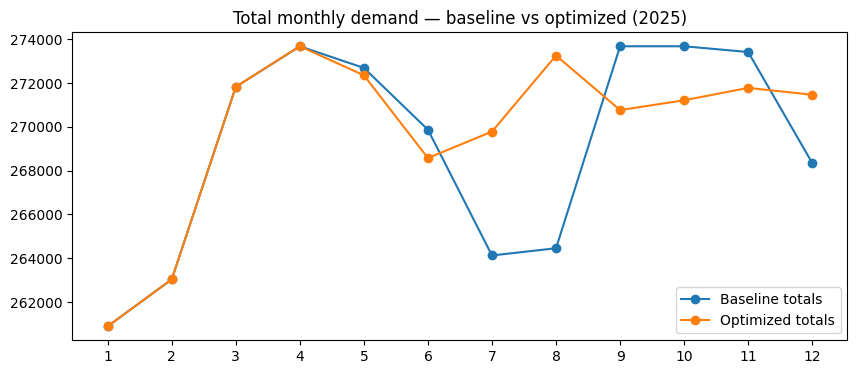

,product,lost_sales,demand,lost_sales_pct
3,FN,23577.555556,548464.111111,4.298833
1,CL,11659.583333,386931.419893,3.013346
4,HP,11596.000000,881444.000000,1.315569
2,CN,7625.555556,635209.486060,1.200479
0,AH,6295.331307,786566.578890,0.800356


In [12]:

sim_detail = best['sim_detail'].copy()
sim_detail['month_name'] = sim_detail['month'].map(NUM_TO_MONTH)

# Monthly totals
plt.figure(figsize=(10,4))
plt.plot(baseline_out['monthly_totals'].index, baseline_out['monthly_totals'].values, marker='o', label='Baseline totals')
plt.plot(best['monthly_totals'].index, best['monthly_totals'].values, marker='o', label='Optimized totals')
plt.xticks(range(1,13))
plt.title(f'Total monthly demand — baseline vs optimized ({TARGET_YEAR})')
plt.legend()
plt.show()

# Capacity binding summary
cap_bind = sim_detail.groupby('product').agg(
    lost_sales=('lost_sales','sum'),
    demand=('final_demand','sum')
).reset_index()
cap_bind['lost_sales_pct'] = 100.0 * cap_bind['lost_sales'] / cap_bind['demand'].clip(lower=1.0)
cap_bind.sort_values('lost_sales', ascending=False)


## 9) Optimize under uncertainty (Monte Carlo)

We simulate:
- baseline demand noise (from baseline residual std)
- effect noise (from effect model RMSE)

We report:
- Expected profit
- P10 / P50 / P90
- CVaR(α) (average of worst α fraction)


In [13]:

# =========================
# 9) Uncertainty simulation (final report)
# =========================
def cvar(values, alpha=0.10):
    v = np.sort(np.array(values))
    k = max(1, int(math.ceil(alpha * len(v))))
    return float(v[:k].mean())

rng = np.random.default_rng(RANDOM_SEED + 123)

# Build a fresh scenario bank for reporting
scenario_bank_rep = []
for _ in range(N_SCENARIOS_REPORT):
    mat = sample_baseline_resid_mat(rng)
    seed = int(rng.integers(0, 2**32-1))
    scenario_bank_rep.append({'baseline_resid_mat': mat, 'seed': seed})

# Baseline and optimized distributions under same scenarios
base_profits_rep, base_vars_rep = [], []
opt_profits_rep, opt_vars_rep = [], []

for sc in scenario_bank_rep:
    out0 = simulate_schedule(
        pd.DataFrame(columns=['product','month','promo_type','discount_pct','duration_days']),
        add_noise=True,
        rng=np.random.default_rng(sc['seed']),
        baseline_resid_mat=sc['baseline_resid_mat']
    )
    out1 = simulate_schedule(
        best_sched,
        add_noise=True,
        rng=np.random.default_rng(sc['seed']),
        baseline_resid_mat=sc['baseline_resid_mat']
    )
    base_profits_rep.append(out0['total_profit'])
    base_vars_rep.append(out0['demand_variance'])
    opt_profits_rep.append(out1['total_profit'])
    opt_vars_rep.append(out1['demand_variance'])

base_profits_rep = np.array(base_profits_rep)
base_vars_rep = np.array(base_vars_rep)
opt_profits_rep = np.array(opt_profits_rep)
opt_vars_rep = np.array(opt_vars_rep)

uplifts_rep = opt_profits_rep - base_profits_rep
uplift_pct_rep = uplifts_rep / np.mean(base_profits_rep) * 100.0

VAR_LIMIT = baseline_var * VAR_LIMIT_RATIO

report = {
    'constraints': {
        'max_promos': int(MAX_PROMOS),
        'no_promo_months': sorted(list(NO_PROMO_MONTHS)),
        'var_limit_ratio': float(VAR_LIMIT_RATIO),
        'var_limit_point': float(VAR_LIMIT),
        'chance_level_required': float(CHANCE_LEVEL),
        'min_mean_uplift_pct': float(MIN_MEAN_UPLIFT_PCT),
    },
    'baseline_point': {
        'profit': float(baseline_profit),
        'variance': float(baseline_var),
    },
    'optimized_point': {
        'profit': float(best_profit),
        'variance': float(best_var),
        'profit_improvement_pct': float(improve_pct),
    },
    'mc': {
        'n_scenarios': int(N_SCENARIOS_REPORT),

        'baseline_profit_mean': float(np.mean(base_profits_rep)),
        'baseline_profit_p10': float(np.quantile(base_profits_rep, 0.10)),
        'baseline_profit_p50': float(np.quantile(base_profits_rep, 0.50)),
        'baseline_profit_p90': float(np.quantile(base_profits_rep, 0.90)),
        'baseline_profit_cvar': float(cvar(base_profits_rep, RISK_ALPHA_CVAR)),
        'baseline_var_mean': float(np.mean(base_vars_rep)),
        'baseline_prob_var_ok': float(np.mean(base_vars_rep <= VAR_LIMIT)),

        'optimized_profit_mean': float(np.mean(opt_profits_rep)),
        'optimized_profit_p10': float(np.quantile(opt_profits_rep, 0.10)),
        'optimized_profit_p50': float(np.quantile(opt_profits_rep, 0.50)),
        'optimized_profit_p90': float(np.quantile(opt_profits_rep, 0.90)),
        'optimized_profit_cvar': float(cvar(opt_profits_rep, RISK_ALPHA_CVAR)),
        'optimized_var_mean': float(np.mean(opt_vars_rep)),
        'optimized_var_p90': float(np.quantile(opt_vars_rep, 0.90)),
        'optimized_prob_var_ok': float(np.mean(opt_vars_rep <= VAR_LIMIT)),

        'uplift_mean': float(np.mean(uplifts_rep)),
        'uplift_p10': float(np.quantile(uplifts_rep, 0.10)),
        'uplift_p50': float(np.quantile(uplifts_rep, 0.50)),
        'uplift_p90': float(np.quantile(uplifts_rep, 0.90)),
        'uplift_pct_mean': float(np.mean(uplift_pct_rep)),
        'uplift_pct_p10': float(np.quantile(uplift_pct_rep, 0.10)),
        'uplift_pct_p90': float(np.quantile(uplift_pct_rep, 0.90)),
        'prob_uplift_positive': float(np.mean(uplifts_rep > 0.0)),
        'uplift_cvar': float(cvar(uplifts_rep, RISK_ALPHA_CVAR)),
    }
}

report


{'constraints': {'max_promos': 3,
  'no_promo_months': [1, 2, 3],
  'var_limit_ratio': 1.0,
  'var_limit_point': 21123803.394606303,
  'chance_level_required': 0.9,
  'min_mean_uplift_pct': 0.0},
 'baseline_point': {'profit': 3693431976.3500004,
  'variance': 21123803.394606303},
 'optimized_point': {'profit': 3710165744.6984987,
  'variance': 14484045.77286811,
  'profit_improvement_pct': 0.4530682697190258},
 'mc': {'n_scenarios': 500,
  'baseline_profit_mean': 3750106264.672,
  'baseline_profit_p10': 3597957798.599999,
  'baseline_profit_p50': 3784388386.1999993,
  'baseline_profit_p90': 3861952525.4,
  'baseline_profit_cvar': 3597957798.5999994,
  'baseline_var_mean': 857355571.9319444,
  'baseline_prob_var_ok': 0.0,
  'optimized_profit_mean': 3761304564.143971,
  'optimized_profit_p10': 3607591923.8419976,
  'optimized_profit_p50': 3796034035.896397,
  'optimized_profit_p90': 3876454859.708519,
  'optimized_profit_cvar': 3601436381.5682545,
  'optimized_var_mean': 846384833.936798

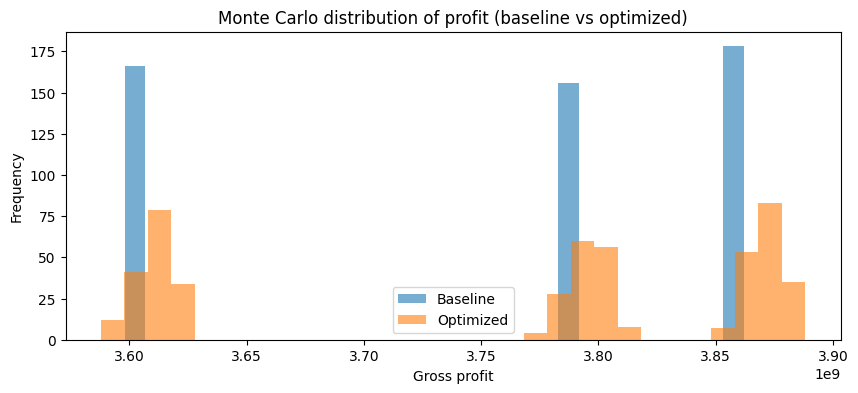

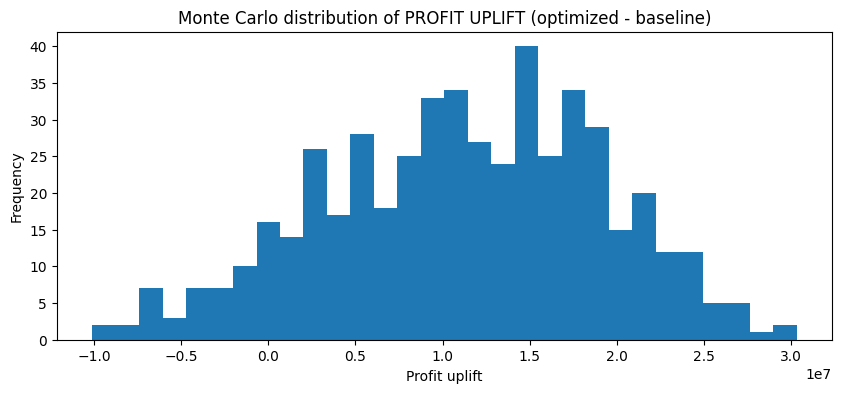

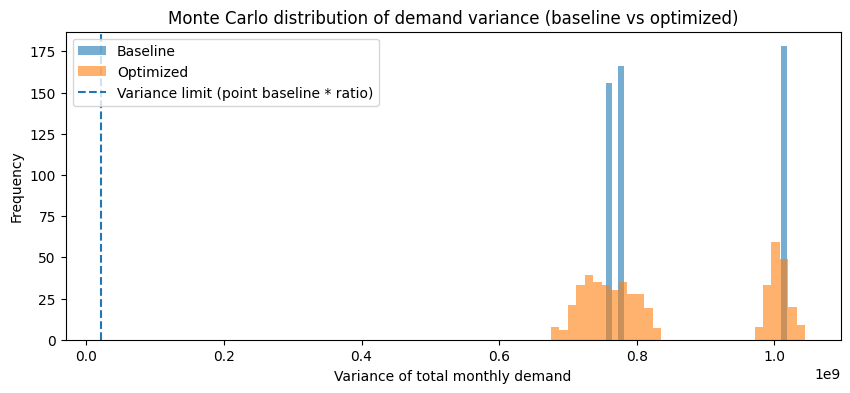

In [14]:

# Visual diagnostics: baseline vs optimized under uncertainty
plt.figure(figsize=(10,4))
plt.hist(base_profits_rep, bins=30, alpha=0.6, label='Baseline')
plt.hist(opt_profits_rep, bins=30, alpha=0.6, label='Optimized')
plt.title('Monte Carlo distribution of profit (baseline vs optimized)')
plt.xlabel('Gross profit')
plt.ylabel('Frequency')
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.hist(uplifts_rep, bins=30)
plt.title('Monte Carlo distribution of PROFIT UPLIFT (optimized - baseline)')
plt.xlabel('Profit uplift')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10,4))
plt.hist(base_vars_rep, bins=30, alpha=0.6, label='Baseline')
plt.hist(opt_vars_rep, bins=30, alpha=0.6, label='Optimized')
plt.axvline(VAR_LIMIT, linestyle='--', label='Variance limit (point baseline * ratio)')
plt.title('Monte Carlo distribution of demand variance (baseline vs optimized)')
plt.xlabel('Variance of total monthly demand')
plt.ylabel('Frequency')
plt.legend()
plt.show()


## 10) Save outputs (schedule + summary)

This produces:
- `results_problem3/problem3_schedule.csv`
- `results_problem3/problem3_summary.json`


In [15]:

# =========================
# 10) Save outputs
# =========================
out_sched = effects.copy()
out_sched = out_sched.rename(columns={'month_name':'month'})
out_sched.to_csv(RESULTS_DIR / 'problem3_schedule.csv', index=False)

with open(RESULTS_DIR / 'problem3_summary.json', 'w') as f:
    json.dump(report, f, indent=2)

print('Wrote:')
print(' ', RESULTS_DIR / 'problem3_schedule.csv')
print(' ', RESULTS_DIR / 'problem3_summary.json')

out_sched


Wrote:
  results_problem3\problem3_schedule.csv
  results_problem3\problem3_summary.json


,product,month,promo_type,discount_pct,duration_days,lift_pct,prebuy_pct,postbuy_pct,margin_impact_pct
0,CN,Aug,dealer_spiff,3.4,21,18.948788,3.711993,6.463497,1.233582
1,AH,Dec,financing,0.0,14,14.370461,4.163711,5.976735,1.523256
2,CL,Jul,financing,0.0,14,20.801728,2.554529,6.463497,1.169767



## 11) Notes for improving score (what we fixed)

This notebook now includes the key "expected quality" fixes:

- **Baseline + optimized Monte Carlo comparison** under the *same* scenarios (common random numbers).
- **Chance constraint** for volatility: schedule selection enforces `P(variance ≤ limit) ≥ CHANCE_LEVEL`.
- **Calibrated uncertainty**: baseline demand noise uses **residual bootstrap by year** (preserves seasonality + cross-product correlation),
  and promo-effect noise bootstraps **year-CV residuals** instead of i.i.d. Gaussian.
- **OOD guardrails**: candidates can be restricted to **observed** (promo_type, discount, duration) tuples to prevent the optimizer
  from exploiting extrapolation.

Optional upgrades:
- Replace effect model with **DML / EconML** for stronger causal framing.
- Use a solver (OR-Tools) only after linearizing approximations; brute force remains simplest for nonlinear cannibalization + variance.


In [ ]:
from pathlib import Path
import joblib
import sklearn
import platform
from datetime import datetime

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

artifact = {
    # trained models
    "baseline_models": baseline_models,   # dict: product -> regressor
    "effect_models": effect_models,       # dict: target -> sklearn Pipeline

    # metadata needed for correct inference
    "TARGET_YEAR": TARGET_YEAR,
    "signal_cols": signal_cols,
    "baseline_feature_cols": baseline_feature_cols,
    "promo_feature_cols": promo_feature_cols,
    "MONTH_TO_NUM": MONTH_TO_NUM,
    "NUM_TO_MONTH": NUM_TO_MONTH,

    # environment (useful for reproducibility)
    "sklearn_version": sklearn.__version__,
    "python_version": platform.python_version(),
    "saved_at": datetime.utcnow().isoformat() + "Z",
}

model_path = MODEL_DIR / "event_impact_optimization_models.joblib"
joblib.dump(artifact, model_path, compress=3)
print("Saved model artifact to:", model_path.resolve())


Saved model artifact to: D:\Projects\@Scale AI Hackathon\Codes\models\p3_models.joblib


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------
# Load trained artifact
# -----------------------------
artifact = joblib.load("models/event_impact_optimization_models.joblib")

baseline_models = artifact["baseline_models"]
effect_models = artifact["effect_models"]
signal_cols = artifact["signal_cols"]
baseline_feature_cols = artifact["baseline_feature_cols"]
promo_feature_cols = artifact["promo_feature_cols"]
MONTH_TO_NUM = artifact["MONTH_TO_NUM"]

TARGET_YEAR = artifact["TARGET_YEAR"]

# -----------------------------
# Load raw data
# -----------------------------
DATA_DIR = Path("data")  # change if needed

demand_history = pd.read_csv(DATA_DIR / "demand_history.csv")
promotion_history = pd.read_csv(DATA_DIR / "promotion_history.csv")
external_signals = pd.read_csv(DATA_DIR / "external_signals.csv")

# -----------------------------
# Helpers
# -----------------------------
def add_time_features(df, month_col="month"):
    df = df.copy()
    df["month_sin"] = np.sin(2*np.pi*df[month_col]/12.0)
    df["month_cos"] = np.cos(2*np.pi*df[month_col]/12.0)
    return df

def wmape(y_true, y_pred, eps=1e-9):
    return np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + eps)

# -----------------------------
# 1) Test baseline demand model on TARGET_YEAR
# -----------------------------
# Keep totals only
demand = demand_history[demand_history["aps"].astype(str).str.upper() == "ALL"].copy()

# Melt Jan..Dec to long
month_cols = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
month_to_num = {m:i+1 for i,m in enumerate(month_cols)}

demand_long = demand.melt(
    id_vars=["product","year","aps"],
    value_vars=month_cols,
    var_name="month_name",
    value_name="demand_units"
)
demand_long["month"] = demand_long["month_name"].map(month_to_num).astype(int)
demand_long = demand_long.drop(columns=["month_name"])
demand_long = demand_long.merge(external_signals, on=["year","month"], how="left")
demand_long = add_time_features(demand_long, month_col="month")

test_df = demand_long[demand_long["year"] == TARGET_YEAR].copy()

rows = []
for product, df_p in test_df.groupby("product"):
    if product not in baseline_models:
        continue
    X = df_p[baseline_feature_cols]
    y_true = df_p["demand_units"].astype(float).values
    y_pred = baseline_models[product].predict(X)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    w = wmape(y_true, y_pred)
    rows.append([product, mae, rmse, w])

baseline_metrics = pd.DataFrame(rows, columns=["product","MAE","RMSE","wMAPE"])
display(baseline_metrics.sort_values("product"))

print("Overall wMAPE:", wmape(
    test_df["demand_units"].astype(float).values,
    np.concatenate([
        baseline_models[p].predict(test_df[test_df["product"]==p][baseline_feature_cols])
        for p in sorted(test_df["product"].unique())
        if p in baseline_models
    ])
))

# -----------------------------
# 2) Test promo-effect models (if TARGET_YEAR promo rows exist; else use max year)
# -----------------------------
promo = promotion_history.copy()

# normalize month into month_num (handles either month string or month_num already)
if "month_num" not in promo.columns:
    if "month" in promo.columns and promo["month"].dtype == object:
        promo["month_num"] = promo["month"].map(MONTH_TO_NUM).astype(int)
    elif "month" in promo.columns:
        promo["month_num"] = promo["month"].astype(int)
    else:
        raise ValueError("promotion_history must have month or month_num")

promo = promo.merge(
    external_signals,
    left_on=["year","month_num"],
    right_on=["year","month"],
    how="left",
    suffixes=("","_sig")
)

eval_year = TARGET_YEAR if (promo["year"] == TARGET_YEAR).any() else int(promo["year"].max())
promo_eval = promo[promo["year"] == eval_year].copy()

targets = ["lift_pct","prebuy_pct","postbuy_pct","margin_impact_pct"]
effect_rows = []

for tgt in targets:
    if tgt not in promo_eval.columns:
        continue
    X = promo_eval[promo_feature_cols].copy()
    y_true = promo_eval[tgt].astype(float).values
    y_pred = effect_models[tgt].predict(X)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    effect_rows.append([tgt, eval_year, mae, rmse])

effect_metrics = pd.DataFrame(effect_rows, columns=["target","eval_year","MAE","RMSE"])
display(effect_metrics)


,product,MAE,RMSE,wMAPE
0,AH,12339.569444,14974.928313,0.168118
1,CL,7469.180556,8259.614353,0.214431
2,CN,9041.629630,10463.149557,0.163345
3,FN,9537.166667,11108.648941,0.190446
4,HP,14527.666667,16695.714405,0.178675


Overall wMAPE: 0.36376876190526414


,target,eval_year,MAE,RMSE
0,lift_pct,2025,5.150377,6.057695
1,prebuy_pct,2025,1.287583,1.685685
2,postbuy_pct,2025,1.719950,2.084332
3,margin_impact_pct,2025,0.903056,1.139594
